In [1]:
import os
print(os.getcwd())
print(sorted(os.listdir()))

/Users/raceee-g/Desktop/Markov_Switching_AR
['.DS_Store', '.ipynb_checkpoints', 'Untitled1.ipynb', '__init__.py', '__pycache__', 'adapter.py', 'data', 'model_utils.ipynb', 'model_utils.py', 'test_basic.ipynb', 'test_model.ipynb', 'untitled', 'untitled1']


In [2]:
from model_utils import MSARConfig, run_full_msar_pipeline, plot_regime_probabilities

print("model imports successful")

model imports successful


In [3]:
config = MSARConfig(
    ticker="SPY",
    start_date="2019-01-01",
    end_date="2025-01-01",
    train_ratio=0.7,
    val_ratio=0.15,
    k_regimes=2,
    order=1,
    trend="c",
)

print(config)

MSARConfig(ticker='SPY', start_date='2019-01-01', end_date='2025-01-01', train_ratio=0.7, val_ratio=0.15, k_regimes=2, order=1, switching_ar=False, switching_variance=True, trend='c')


In [4]:
outputs = run_full_msar_pipeline(config)

Loading data from cache...


In [5]:
outputs["best_config"]

{'k_regimes': 2,
 'order': 1,
 'switching_variance': True,
 'trend': 'c',
 'switching_ar': False}

In [6]:
outputs["tuning_table"]

,k_regimes,order,switching_variance,aic,bic,llf,error
0,2,1,True,-6445.883321,-6411.154249,3229.941660,None
1,2,2,True,-6449.537093,-6409.854311,3232.768547,None
2,2,1,False,-6141.617231,-6111.849455,3076.808616,None
3,2,2,False,-6025.481525,-5990.759091,3019.740762,None


In [7]:
outputs["validation_metrics"]

{'MSE': 5.7166675538702744e-05,
 'MAE': 0.0059447961821535574,
 'RMSE': 0.00756086473485029,
 'Directional_Accuracy': 0.5575221238938053}

In [8]:
outputs["validation_forecasts"].head()

,actual,pred,error
2023-03-15,-0.006274,-0.002123,-0.004151
2023-03-16,0.017393,0.000798,0.016595
2023-03-17,-0.011761,-0.002042,-0.009719
2023-03-20,0.009570,0.001031,0.008539
2023-03-21,0.013045,-0.000571,0.013616


<Axes: title={'center': 'Actual vs Predicted Returns'}>

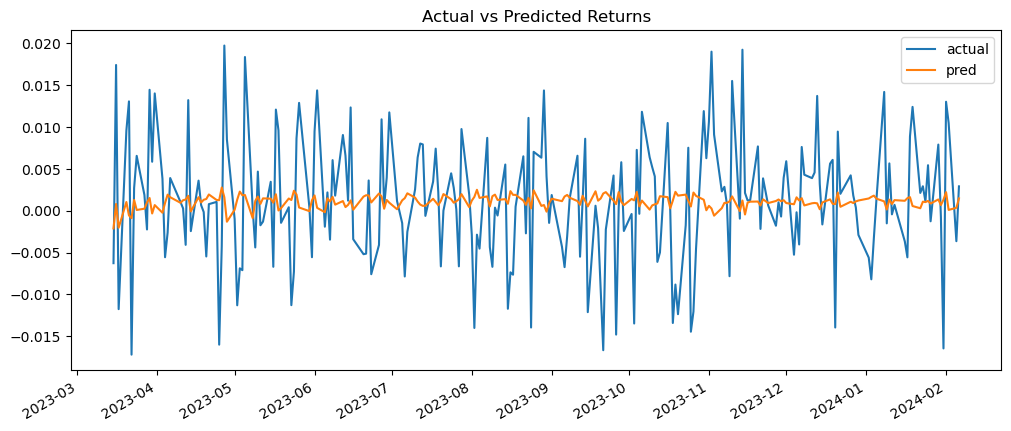

In [9]:
outputs["validation_forecasts"][["actual", "pred"]].plot(
    figsize=(12, 5),
    title="Actual vs Predicted Returns"
)

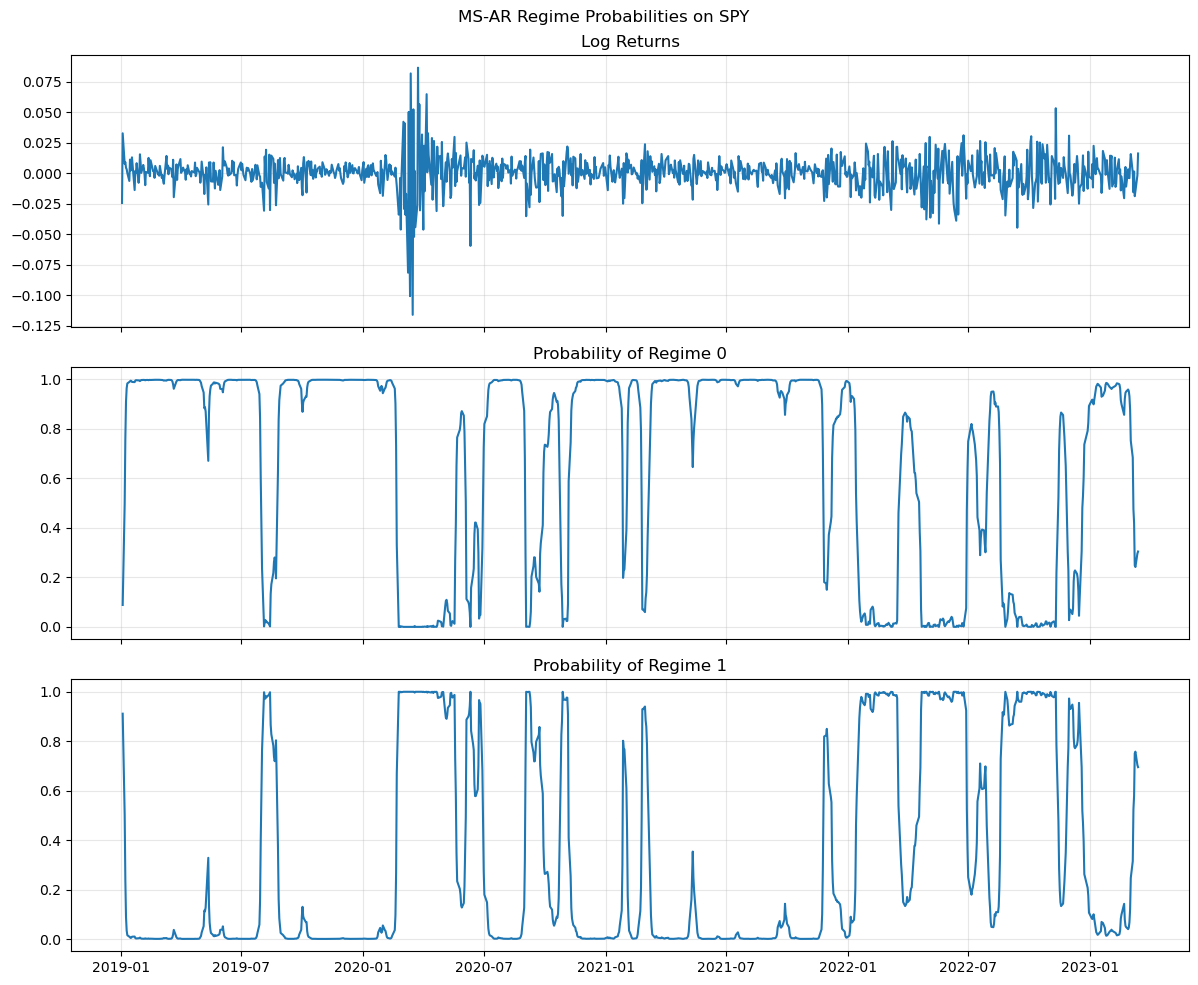

In [10]:
plot_regime_probabilities(
    outputs["best_result"],
    outputs["train"]["return"],
    title="MS-AR Regime Probabilities on SPY"
)